In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [3]:
from sklearn.datasets import load_diabetes
data = load_diabetes() 

In [4]:
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [8]:
df = pd.DataFrame(data.data, columns = data.feature_names)
df['progression'] = pd.Series(data.target)

In [9]:
df.head

<bound method NDFrame.head of           age       sex       bmi        bp        s1        s2        s3  \
0    0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1   -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2    0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3   -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4    0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   
..        ...       ...       ...       ...       ...       ...       ...   
437  0.041708  0.050680  0.019662  0.059744 -0.005697 -0.002566 -0.028674   
438 -0.005515  0.050680 -0.015906 -0.067642  0.049341  0.079165 -0.028674   
439  0.041708  0.050680 -0.015906  0.017293 -0.037344 -0.013840 -0.024993   
440 -0.045472 -0.044642  0.039062  0.001215  0.016318  0.015283 -0.028674   
441 -0.045472 -0.044642 -0.073030 -0.081413  0.083740  0.027809  0.173816   

           s4        s5        s6  progressio

In [11]:
# split data into X and y
y = df['progression']
X = df.drop('progression',axis=1)

# standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# get training and testing data 
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [12]:
# define the model 
model = LinearRegression()

# fit the model 
model.fit(X_train, y_train)

# get predictions on the test set 
y_pred = model.predict(X_test)

# calculate performance metrics
print("MSE:",mean_squared_error(y_test, y_pred))

MSE: 2900.193628493482


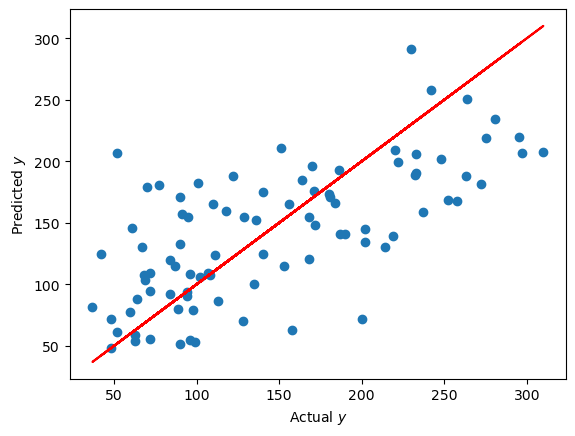

In [13]:
plt.scatter(y_test,y_pred)
plt.plot(y_test,y_test,"r") # perfect model line
plt.ylabel("Predicted $y$")
plt.xlabel("Actual $y$")
plt.show()

In [15]:
import pickle

model_save_path= "mlr_model.pkl"

with open(model_save_path, 'wb') as file:
    pickle.dump(model, file)

In [16]:
model_load_path = "mlr_model.pkl"
with open(model_load_path, 'rb') as file:
    unpickled_model = pickle.load(file)

In [18]:
y_pred = unpickled_model.predict(X_test)

In [22]:
print("MSE:", mean_squared_error(y_test, y_pred))

MSE: 2900.193628493482


We are provided with the Crop_yield dataset that contains various factors that could influence the yield of a particular crop across different regions.

We are interested in how some features, namely Temperature, Rainfall, Fertilizer_Usage, and Pesticide_Usage, influence the yield of the crop.

In [24]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pickle

In [25]:
#import dataset
df = pd.read_csv('https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Data/Python/Crop_yield.csv', index_col=0)
df.head()

,Temperature,Rainfall,Soil_Type,Fertilizer_Usage,Pesticide_Usage,Irrigation,Crop_Variety,Yield
Region,,,,,,,,
East,23.152156,803.362573,Clayey,204.792011,20.767590,1,Variety B,40.316318
West,19.382419,571.567670,Sandy,256.201737,49.290242,0,Variety A,26.846639
North,27.895890,-8.699637,Loamy,222.202626,25.316121,0,Variety C,-0.323558
East,26.741361,897.426194,Loamy,187.984090,17.115362,0,Variety C,45.440871
East,19.090286,649.384694,Loamy,110.459549,24.068804,1,Variety B,35.478118


In [26]:
df.shape

(1000, 8)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, East to East
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Temperature       1000 non-null   float64
 1   Rainfall          1000 non-null   float64
 2   Soil_Type         1000 non-null   object 
 3   Fertilizer_Usage  1000 non-null   float64
 4   Pesticide_Usage   1000 non-null   float64
 5   Irrigation        1000 non-null   int64  
 6   Crop_Variety      1000 non-null   object 
 7   Yield             1000 non-null   float64
dtypes: float64(5), int64(1), object(2)
memory usage: 70.3+ KB


In [42]:
df = df.reset_index()
df = pd.get_dummies(df, drop_first=True, dtype=int)

In [43]:
df.head(6)

,level_0,index,Temperature,Rainfall,Fertilizer_Usage,Pesticide_Usage,Irrigation,Yield,Soil_Type_Loamy,Soil_Type_Sandy,Crop_Variety_Variety B,Crop_Variety_Variety C,Region_North,Region_South,Region_West
0,0,0,23.152156,803.362573,204.792011,20.767590,1,40.316318,False,False,True,False,False,False,False
1,1,1,19.382419,571.567670,256.201737,49.290242,0,26.846639,False,True,False,False,False,False,True
2,2,2,27.895890,-8.699637,222.202626,25.316121,0,-0.323558,True,False,False,True,True,False,False
3,3,3,26.741361,897.426194,187.984090,17.115362,0,45.440871,True,False,False,True,False,False,False
4,4,4,19.090286,649.384694,110.459549,24.068804,1,35.478118,True,False,True,False,False,False,False
5,5,5,29.177471,891.283651,156.499380,27.607213,1,46.600052,True,False,False,False,False,False,True


In [38]:
X = df.drop(columns=['Yield']) 
y = df['Yield']
#split thedataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
#define object model 
model = LinearRegression()
model.fit(X_train, y_train)

#predictions on test data
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test MSE: {mse}")
print(f"Test R-squared: {r2}")


Test MSE: 0.26018960382022455
Test R-squared: 0.9971906700084244


Exercise 2

We want to be able to conveniently retrieve and use the model for predictions in future. We therefore need to persist the trained model by saving it to a file.

Use the pickle library to serialise the model and store it in a file named crop_yield_model.pkl.

In [45]:
model_save_path = 'crop_yield_model.pkl'

with open(model_save_path, 'wb') as file:
    pickle.dump(model,file)

Exercise 3

We have received a new set of conditions for which we need to predict the crop yield. To accomplish this, we'll utilise the model we previously trained and saved.

New conditions:

Temperature – 25
Rainfall – 150
Fertilizer usage – 200
Pesticide usage – 30
Prepare the new data, load the saved model, and use it to make predictions on the given feature values.



In [49]:
new_conditions = { 'Temperature': [25], 'Rainfall': [150], 'Fertilizer_Usage':[200],
                  'Pesticide_Usage': [30],'Irrigation': [1],
    'Soil_Type_Loamy':[1],          # 1 because you chose Loamy
    'Soil_Type_Sandy':[0],          # 0 because it's not Sandy
    'Crop_Variety_Variety B':[1],   # 1 because you chose Variety B
    'Crop_Variety_Variety C':[0],   # 0 because it's not Variety C
    'Region_North':[0],             # 0 because it's East
    'Region_South':[0],             # 0 because it's East
    'Region_West': [0]               # 0 because it's East
}}
new_conditions_df = pd.DataFrame(new_conditions)

model_load_path = 'crop_yield_model.pkl'

with open(model_load_path, 'rb') as file:
    unpickled_model = pickle.load(file)

predicted_yield = unpickled_model.predict(new_conditions_df)

print(f"Predicted Yield for the new conditions: {predicted_yield[0]} tonnes per hectare")

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Crop_Variety
- Region
- Soil_Type
Feature names seen at fit time, yet now missing:
- Crop_Variety_Variety B
- Crop_Variety_Variety C
- Region_North
- Region_South
- Region_West
- ...
